In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# loading the dataset

In [2]:
kb = pd.read_csv('data.csv')
kb.head()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0


In [3]:
kb.tail()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
1383,0.44549,5.5,8.0,51.0,41.0
1384,0.52466,4.9,6.5,63.0,37.0
1385,0.88197,3.9,6.2,54.0,36.0
1386,0.47336,3.5,7.3,61.0,34.0
1387,0.58119,3.7,9.7,79.0,35.0


In [4]:
kb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Socioeconomic Score  1388 non-null   float64
 1   Study Hours          1388 non-null   float64
 2   Sleep Hours          1388 non-null   float64
 3   Attendance (%)       1388 non-null   float64
 4   Grades               1388 non-null   float64
dtypes: float64(5)
memory usage: 54.3 KB


## Checking for missing values

In [5]:
kb.isnull().sum()

Socioeconomic Score    0
Study Hours            0
Sleep Hours            0
Attendance (%)         0
Grades                 0
dtype: int64

## checking for duplicates

In [6]:
kb.duplicated().sum()

0

In [7]:
kb.columns = kb.columns.str.replace(' ', '_')
kb.head(10)

,Socioeconomic_Score,Study_Hours,Sleep_Hours,Attendance_(%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0
5,0.98320,3.4,9.0,47.0,51.0
6,0.56648,7.9,8.1,63.0,54.0
7,0.93487,1.4,8.0,47.0,34.0
8,0.46660,5.4,8.8,67.0,39.0
9,0.62130,1.4,9.6,42.0,34.0


# ***VISUALIZATION***

### Distplot

/var/folders/1h/jy2dct716gl3frd5gbbhyn7h0000gn/T/ipykernel_12526/2065440316.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(kb['Grades'])


<Axes: xlabel='Grades', ylabel='Density'>

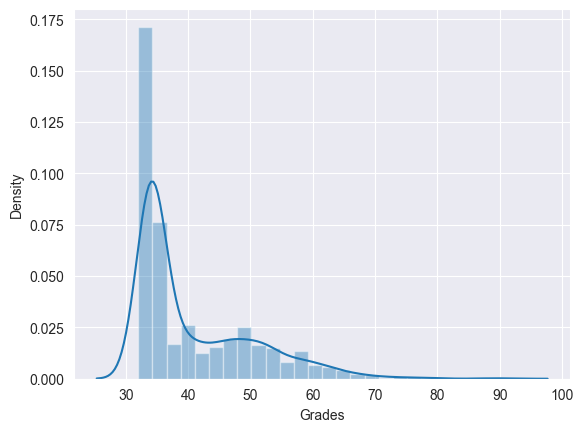

In [8]:
sns.set_style('darkgrid')
sns.distplot(kb['Grades'])

/var/folders/1h/jy2dct716gl3frd5gbbhyn7h0000gn/T/ipykernel_12526/3689444977.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(kb['Attendance_(%)'] )


<Axes: xlabel='Attendance_(%)', ylabel='Density'>

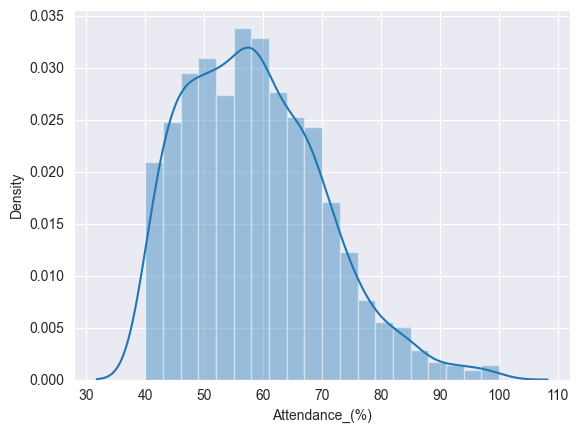

In [9]:
sns.distplot(kb['Attendance_(%)'] )

### JOINT PLOT

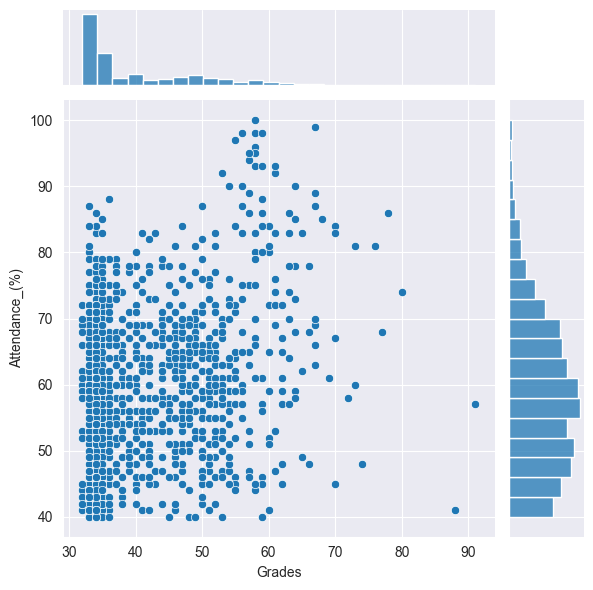

In [10]:
sns.jointplot(x='Grades', y='Attendance_(%)', data=kb)

### PAIR PLOT

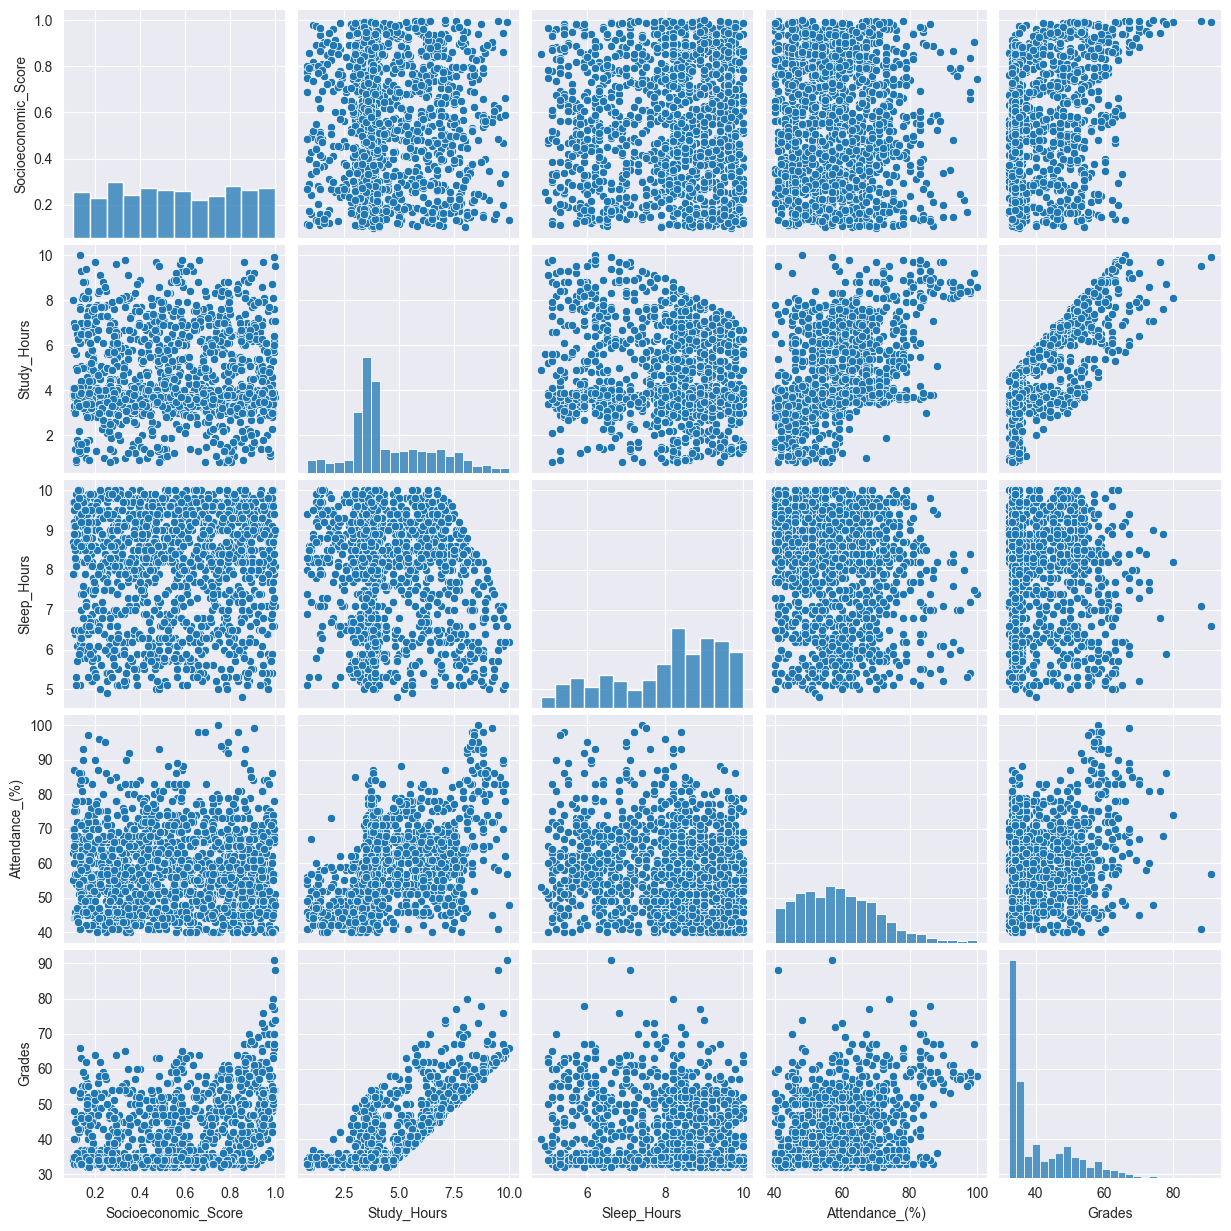

In [11]:
sns.pairplot(kb)

### BOXPLOT

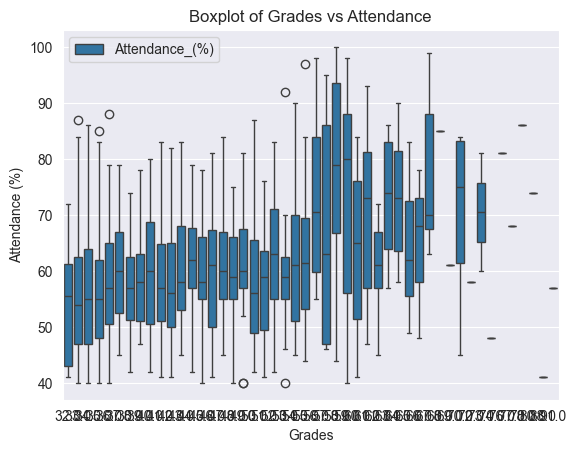

In [12]:
sns.boxplot(x = 'Grades',y = 'Attendance_(%)', data = kb)
plt.title('Boxplot of Grades vs Attendance')
plt.xlabel('Grades')
plt.ylabel('Attendance (%)')
plt.legend(['Attendance_(%)'])
plt.show()

### HEATMAP

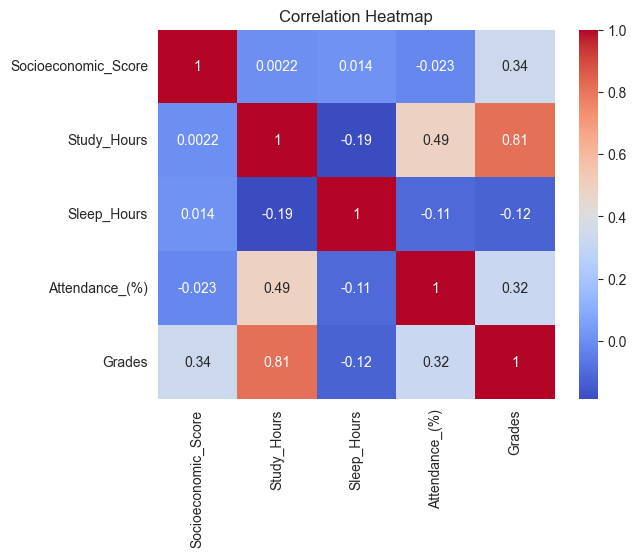

In [13]:
sns.heatmap(kb.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ***MACHINE LEARNING MODELS***

## **LINEAR REGRESSION**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [15]:
y = kb['Grades']
x = kb.drop('Grades', axis=1)

In [16]:
X = pd.get_dummies(x, drop_first=True)

### SPLITTING THE DATA INTO TRAIN, TEST AND SPLITTING

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((1110, 4), (278, 4), (1110,), (278,))

### Building the model

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predicting the results

In [19]:
y_pred = model.predict(x_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('R^2 Score:', r2)
print('Mean Squared Error:', mse)

Mean Absolute Error: 3.386174501268349
R^2 Score: 0.7446674729714068
Mean Squared Error: 19.272537728751253


# ***DECISION TREE***

In [21]:
from sklearn.tree import DecisionTreeRegressor

In [22]:
dtree = DecisionTreeRegressor(random_state=42)
dtree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Making predictions

In [23]:
boi = dtree.predict(x_test)
print(boi)

[41. 33. 33. 32. 34. 35. 52. 33. 45. 36. 33. 40. 33. 34. 33. 40. 34. 35.
 57. 33. 37. 59. 53. 34. 32. 32. 34. 42. 35. 34. 33. 32. 35. 46. 35. 54.
 33. 33. 33. 35. 37. 34. 33. 33. 34. 73. 36. 36. 60. 39. 33. 59. 34. 33.
 33. 45. 34. 34. 52. 33. 35. 59. 36. 60. 57. 35. 33. 35. 38. 44. 52. 34.
 35. 33. 33. 47. 59. 34. 34. 37. 34. 35. 33. 42. 39. 35. 49. 52. 35. 33.
 56. 37. 47. 45. 35. 56. 33. 43. 35. 33. 50. 35. 35. 67. 37. 64. 34. 34.
 54. 50. 34. 35. 33. 35. 41. 37. 37. 35. 33. 54. 42. 34. 35. 41. 35. 48.
 49. 37. 34. 45. 35. 32. 45. 33. 47. 34. 35. 35. 35. 50. 32. 37. 35. 33.
 38. 35. 34. 34. 34. 47. 61. 34. 34. 34. 33. 33. 60. 64. 57. 33. 34. 33.
 46. 46. 35. 35. 53. 46. 46. 45. 38. 33. 49. 36. 59. 38. 55. 33. 35. 58.
 34. 34. 46. 34. 35. 34. 34. 33. 37. 65. 59. 34. 34. 39. 34. 35. 49. 35.
 33. 35. 41. 48. 34. 38. 51. 33. 48. 37. 42. 34. 35. 34. 34. 34. 37. 34.
 44. 33. 41. 34. 48. 42. 35. 38. 48. 35. 34. 34. 49. 34. 33. 36. 56. 34.
 34. 33. 34. 45. 33. 51. 34. 34. 34. 39. 41. 33. 36

In [24]:
mae_dtree = mean_absolute_error(y_test, boi)
r2_dtree = r2_score(y_test, boi)
mse_dtree = mean_squared_error(y_test, boi)

print('Decision Tree Regressor - Mean Absolute Error:', mae_dtree)
print('Decision Tree Regressor - R^2 Score:', r2_dtree)
print('Decision Tree Regressor - Mean Squared Error:', mse_dtree)

Decision Tree Regressor - Mean Absolute Error: 1.316546762589928
Decision Tree Regressor - R^2 Score: 0.9523434671464777
Decision Tree Regressor - Mean Squared Error: 3.597122302158273


# ***KNN***

In [25]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred2 = knn.predict(x_test)

In [26]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
y_pred2 = knn.predict(x_test)
print(y_pred2)

[50.  40.4 34.6 36.  34.2 34.4 49.6 33.8 42.8 39.  35.4 43.  35.4 34.2
 37.2 41.8 33.6 34.  39.  39.6 43.  59.2 52.8 34.4 34.  33.2 36.8 34.4
 34.4 33.6 35.6 36.6 33.6 34.2 35.6 52.4 34.2 34.  35.8 36.8 36.8 35.
 41.8 35.6 36.8 58.2 34.4 40.8 60.4 35.6 35.4 49.8 34.6 34.6 33.4 33.8
 38.  37.8 52.4 34.8 34.  61.  38.2 64.2 52.6 39.8 34.8 33.6 36.4 42.2
 52.  35.8 34.8 33.8 33.8 48.6 47.6 40.2 33.6 36.6 34.  33.6 37.  48.8
 34.6 34.4 53.8 33.8 34.6 34.2 49.6 42.2 38.6 49.6 34.  53.6 36.8 41.8
 34.  34.4 47.  34.  37.4 43.2 40.6 41.  34.6 34.  54.6 35.2 35.6 39.6
 37.  35.2 44.8 33.4 36.4 33.6 34.2 59.4 37.8 34.  34.8 37.  35.4 49.6
 51.8 38.4 34.  47.4 34.2 33.4 49.  33.8 39.4 34.4 35.8 33.8 35.4 51.2
 35.6 40.4 38.8 33.6 40.6 33.2 34.2 38.  33.4 34.4 59.4 33.4 34.6 34.
 34.2 34.2 54.2 61.  48.2 36.2 34.2 36.2 48.6 34.8 33.4 35.2 36.2 49.2
 47.  41.6 36.2 37.  50.  35.8 43.2 39.8 37.  33.8 34.  56.2 34.2 35.
 48.4 34.8 34.2 34.4 34.2 36.6 44.8 56.6 60.  41.8 34.6 45.6 34.4 33.8
 60.8 34.

# ***SVM***

In [37]:
from sklearn.svm import SVR
svm_model = SVR(kernel='rbf')
svm_model.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [38]:
y_pred3 = svm_model.predict(x_test)
print(y_pred3)

[36.6830771  35.28636435 35.0699113  38.44983727 39.02625612 33.20764383
 38.7429086  36.57831024 36.50982623 42.37939922 36.50094892 40.65907571
 34.89052525 34.74314881 35.52405635 45.99585961 39.96681656 34.95022993
 38.64033583 35.7125942  36.67360807 52.13061767 37.0846387  35.84471376
 35.23172835 39.18205445 34.8412887  33.92618649 35.41698122 33.77800166
 34.79999581 35.45682299 33.18754714 41.6761363  35.63180033 37.93469686
 38.37641336 36.64105523 37.29177221 36.40085443 35.22344615 34.68493258
 35.01889123 35.61117975 36.03981609 47.63504969 35.20690771 36.1788097
 44.13476452 36.68231619 34.4295988  37.76859807 39.70418535 34.74430485
 37.70545872 39.01929472 35.21738023 38.8842542  38.22666004 42.97780422
 34.40780896 46.89966973 37.811625   44.96816913 39.83726044 41.91487752
 35.12120726 33.34289696 34.68524033 39.54473831 39.24395379 34.52098259
 35.54076773 39.74555844 35.98544384 39.45090114 36.92900283 35.69673533
 33.83168971 37.45619478 35.20359473 35.4036674  37.

# ***Random forest***

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [42]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
boi_10 = rf.predict(x_test) # Making predictions with the Random Forest model

In [44]:
mae_10 = mean_absolute_error(y_test, boi_10)
print("Random Forest Regressor - Mean Absolute Error:", mae_10)
mse_10 = mean_squared_error(y_test, boi_10)
print("Random Forest Regressor - Mean Squared Error:", mse_10)
r2_10 = r2_score(y_test, boi_10)
print("Random Forest Regressor - R^2 Score:", r2_10)

Random Forest Regressor - Mean Absolute Error: 0.8930215827338132
Random Forest Regressor - Mean Squared Error: 1.463377697841727
Random Forest Regressor - R^2 Score: 0.9806124169610629
